# Neural Stochastic Differential Equations for Data-Space Forecasting

In this notebook, we explore **Neural Stochastic Differential Equations (Neural SDEs)** as a framework for modeling and forecasting time series directly in data space. Neural SDEs extend Neural ODEs by explicitly incorporating stochasticity into the dynamics, allowing the model to represent not only the average behavior of a system but also its uncertainty.

A standard Neural ODE learns deterministic dynamics of the form:

$$\frac{dx}{dt} = f_\theta(x, t)$$

which produces a single predicted trajectory for a given initial condition. While this is sufficient for many problems, it is limiting in settings where the underlying system is noisy or stochastic. In such cases, a single trajectory prediction fails to capture the range of plausible futures.

Neural SDEs address this limitation by modeling dynamics of the form:

$$dx_t = f_\theta(x_t, t)\,dt + g_\theta(x_t, t)\,dW_t$$

where the additional diffusion term introduces continuous-time noise through Brownian motion. As a result, Neural SDEs define a *distribution over trajectories* rather than a single deterministic path. This makes them particularly well suited for forecasting tasks where uncertainty matters: instead of producing a point prediction, the model can generate a family of trajectories whose spread can be interpreted as a confidence interval over future outcomes.

To study this behavior in a controlled setting, we evaluate Neural SDEs on a synthetic **Ornstein–Uhlenbeck (OU) process**, a classic stochastic process with known analytical mean and variance. This allows us to directly compare learned dynamics against ground truth statistics and to examine how different training objectives affect the model’s ability to capture both the deterministic drift and stochastic diffusion components of the system.

## Neural SDE Architecture

To model stochastic dynamics directly in data space, we parameterize both the **drift** and **diffusion** terms of the SDE using neural networks. Concretely, we represent the system as

$$dx_t = f_\theta(x_t, t)\,dt + g_\phi(x_t, t)\,dW_t,$$

where:
- $f_\theta(x_t, t)$ is the **drift function**, capturing the deterministic component of the dynamics, and
- $g_\phi(x_t, t)$ is the **diffusion function**, controlling the magnitude of stochastic noise.

Both functions are implemented as multilayer perceptrons (MLPs) that take the current state $x_t$ and time $t$ as input. This allows the model to learn **state-dependent** and **time-dependent** dynamics.

### Drift Network

The drift network outputs a scalar value representing the instantaneous deterministic change in the state. It uses a smooth activation function (tanh) to encourage stable dynamics, followed by a learnable scaling parameter that allows the model to adjust the overall magnitude of the drift.

### Diffusion Network

The diffusion network outputs a strictly positive scalar that determines the strength of the noise injected into the system. To ensure positivity, the final layer applies a softplus activation. As with the drift, a learnable scaling parameter allows the model to adapt the noise level during training.

### Simulation via Euler–Maruyama

Given an initial condition $x_0$ and a time grid $\{t_0, \dots, t_T\}$, trajectories are generated by numerically solving the SDE using the **Euler–Maruyama** method. Each forward pass samples a Brownian motion realization, meaning that repeated simulations from the same initial condition naturally produce different trajectories.

As a result, the Neural SDE does not produce a single forecast, but rather a distribution over possible futures. This makes the model well suited for probabilistic forecasting, where both the expected behavior and the uncertainty of the system are of interest.

In [1]:
import equinox as eqx
import diffrax as dfx
import jax
import jax.numpy as jnp


class DriftNet(eqx.Module):
    mlp: eqx.nn.MLP
    scale: jax.Array

    def __init__(self, hidden_size, depth, *, key):
        self.scale = jnp.array(1.0)
        self.mlp = eqx.nn.MLP(
            in_size=2,
            out_size=1,
            width_size=hidden_size,
            depth=depth,
            activation=jax.nn.tanh,
            final_activation=lambda x: x,
            key=key,
        )

    def __call__(self, t, y):
        inp = jnp.stack([t, y])
        return self.scale * self.mlp(inp)[0]


class DiffusionNet(eqx.Module):
    mlp: eqx.nn.MLP
    scale: jax.Array

    def __init__(self, hidden_size, depth, *, key):
        self.scale = jnp.array(1.0)
        self.mlp = eqx.nn.MLP(
            in_size=2,
            out_size=1,
            width_size=hidden_size,
            depth=depth,
            activation=jax.nn.tanh,
            final_activation=jax.nn.softplus,
            key=key,
        )

    def __call__(self, t, y):
        inp = jnp.stack([t, y])
        return self.scale * self.mlp(inp)[0]


class NeuralSDE(eqx.Module):
    drift: DriftNet
    diffusion: DiffusionNet

    def __init__(self, hidden_size=32, depth=2, *, key):
        k1, k2 = jax.random.split(key)
        self.drift = DriftNet(hidden_size, depth, key=k1)
        self.diffusion = DiffusionNet(hidden_size, depth, key=k2)

    def __call__(self, ts, y0, *, key):
        t0, t1 = ts[0], ts[-1]
        dt = ts[1] - ts[0]

        brownian = dfx.VirtualBrownianTree(t0=t0, t1=t1, tol=1e-3, shape=(), key=key)

        drift_term = dfx.ODETerm(lambda t, y, args: self.drift(t, y))
        diff_term = dfx.ControlTerm(lambda t, y, args: self.diffusion(t, y), brownian)

        terms = dfx.MultiTerm(drift_term, diff_term)

        sol = dfx.diffeqsolve(
            terms=terms,
            solver=dfx.Euler(),
            t0=t0,
            t1=t1,
            dt0=dt,
            y0=y0,
            saveat=dfx.SaveAt(ts=ts),
        )
        return sol.ys

## Training Setup

We train the Neural SDE by fitting both the drift and diffusion functions to observed trajectories of the system. Given a fixed time grid and an initial condition, the model generates sample paths by numerically solving the SDE, with each forward pass corresponding to a different realization of the underlying Brownian motion.

The choice of training objective is critical. For stochastic systems, minimizing mean squared error (MSE) between generated and observed trajectories is inappropriate, as it encourages the model to predict the conditional mean and suppress stochastic variability. As a result, MSE-based training fails to recover the true noise structure of the dynamics.

Instead, we train the model using a **likelihood-based objective** derived from Girsanov’s theorem. This loss measures how likely the observed trajectories are under the stochastic dynamics defined by the model and corresponds to a **maximum likelihood estimator** for the drift and diffusion parameters under the chosen SDE discretization. By optimizing this objective, the Neural SDE is encouraged to learn both the deterministic drift and the stochastic diffusion components, allowing it to match the full distribution of trajectories rather than just their mean behavior.

In [2]:
@eqx.filter_value_and_grad
def nll_loss(model, xs, ts):
    """
    xs: (batch, N) observed trajectories
    ts: (N,)
    """
    dt = ts[1] - ts[0]

    def single_loglik(x):
        t = ts[:-1]
        x_t = x[:-1]
        x_tp1 = x[1:]
        dx = x_tp1 - x_t

        f = jax.vmap(lambda ti, xi: model.drift(ti, xi))(t, x_t)
        g = jax.vmap(lambda ti, xi: model.diffusion(ti, xi))(t, x_t)

        # numerical stability
        eps = 1e-6
        g2 = g**2 + eps

        return -0.5 * jnp.sum((dx - f * dt)**2 / (g2 * dt) + jnp.log(g2 * dt))

    # mean negative log likelihood over batch
    return -jnp.mean(jax.vmap(single_loglik)(xs))   # negative log likelihood

@eqx.filter_jit
def train_step(model, opt_state, ts, true_paths):
    loss, grads = nll_loss(model, true_paths, ts)
    updates, opt_state = optimizer.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

## Experiment: Learning a Stochastic Ornstein–Uhlenbeck Process

To evaluate whether Neural SDEs can accurately model stochastic dynamics in data space, we consider a synthetic **Ornstein–Uhlenbeck (OU) process**. The OU process is a classic continuous-time stochastic process with well-understood analytical properties, making it an ideal testbed for validating both qualitative behavior and quantitative statistics learned by the model.

The OU process is defined by the stochastic differential equation:

$$dx_t = -\theta (x_t - \mu)\,dt + \sigma\,dW_t,$$

where:
- $\theta > 0$ controls the rate at which the process reverts to its mean,
- $\mu$ is the long-term mean of the process,
- $\sigma$ determines the strength of the stochastic noise, and
- $W_t$ denotes standard Brownian motion.

This process exhibits mean-reverting behavior while maintaining nonzero variance at all times. Importantly, its time-dependent mean and variance are known in closed form, allowing direct comparison between learned and true dynamics.

### Experimental Setup

We generate a dataset of trajectories by simulating the OU process from a fixed initial condition over a uniform time grid. These trajectories serve as observations for training the Neural SDE. After training, we evaluate the model by generating new trajectories from the learned dynamics and comparing them to the ground truth in two ways:

1. **Qualitative assessment**: Do the generated trajectories exhibit realistic stochastic behavior consistent with the OU process?
2. **Statistical validation**: Do the empirical mean and variance of generated trajectories match the analytical mean and variance of the OU process over time?

This experiment is designed to test whether the Neural SDE can recover both the deterministic drift and stochastic diffusion components of a known process, and whether likelihood-based training enables the model to learn the full distribution of trajectories rather than collapsing to average behavior.

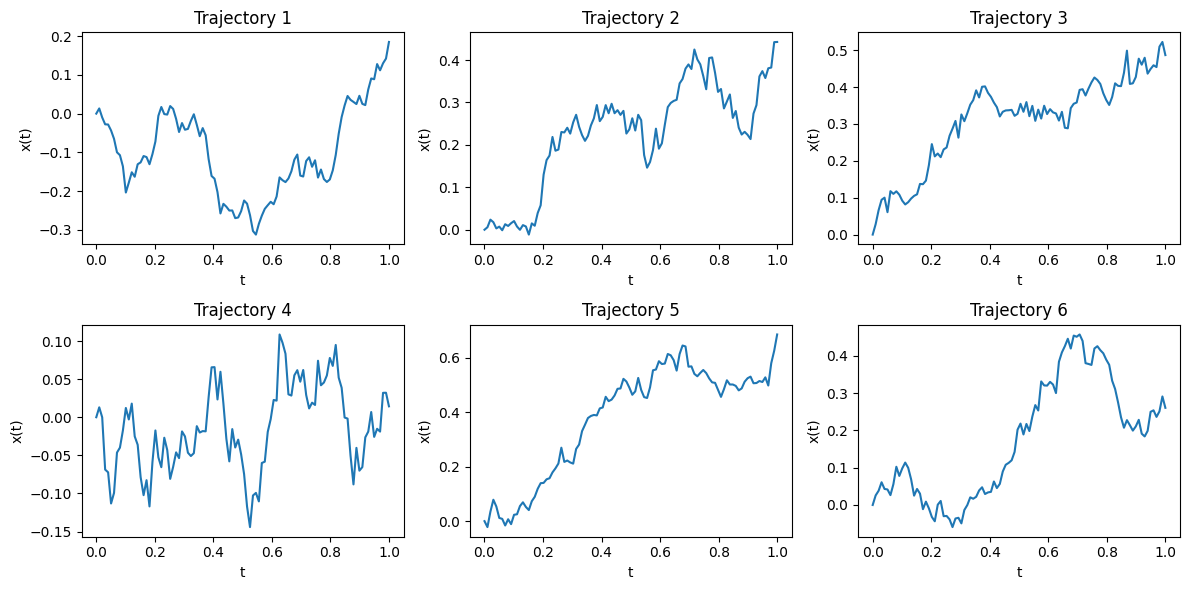

In [3]:
import jax
import jax.numpy as jnp
import diffrax as dfx
import matplotlib.pyplot as plt

# Ornstein–Uhlenbeck parameters
theta = 1.0
mu = 0.5
sigma = 0.3

# Drift and diffusion functions for a scalar SDE
def drift(t, x, args):
    return -theta * (x - mu)

def diffusion(t, x, args):
    return sigma

# Build SDE terms using VirtualBrownianTree (scalar Brownian motion)
def make_terms(key, t0, t1):
    brownian = dfx.VirtualBrownianTree(
        t0=t0,
        t1=t1,
        tol=1e-3,
        shape=(),  # scalar Brownian motion
        key=key,
    )
    drift_term = dfx.ODETerm(drift)
    diff_term = dfx.ControlTerm(diffusion, brownian)
    return dfx.MultiTerm(drift_term, diff_term)

# Simulation settings
t0, t1 = 0.0, 1.0
N = 100
ts = jnp.linspace(t0, t1, N)
dt = (t1 - t0) / (N - 1)

# Simulate one OU trajectory
def simulate_one(key):
    terms = make_terms(key, t0, t1)
    sol = dfx.diffeqsolve(
        terms=terms,
        solver=dfx.Euler(),  # Euler–Maruyama for SDEs
        t0=t0,
        t1=t1,
        dt0=dt,
        y0=0.0,
        saveat=dfx.SaveAt(ts=ts),
    )
    return sol.ys  # (N,)

# Generate trajectories
n_traj = 100
master_key = jax.random.PRNGKey(0)
keys = jax.random.split(master_key, n_traj)
trajectories = jax.vmap(simulate_one)(keys)  # (n_traj, N)

# Visualize a few trajectories
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for i, ax in enumerate(axes.flatten()):
    ax.plot(ts, trajectories[i])
    ax.set_title(f"Trajectory {i+1}")
    ax.set_xlabel("t")
    ax.set_ylabel("x(t)")

plt.tight_layout()
plt.show()

In [4]:
import equinox as eqx
import jax
import jax.numpy as jnp
import optax

# ----------------------------
# Model + training config
# ----------------------------
key_model = jax.random.PRNGKey(0)
model = NeuralSDE(hidden_size=32, depth=2, key=key_model)

optimizer = optax.adam(1e-3)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

num_steps = 1000
batch_size = 32
log_every = 100

# ----------------------------
# Training loop
# ----------------------------
key = jax.random.PRNGKey(42)

for step in range(num_steps):
    key, subkey = jax.random.split(key)

    # Sample a random batch of OU trajectories
    idx = jax.random.choice(subkey, trajectories.shape[0], shape=(batch_size,))
    batch = trajectories[idx]  # (batch_size, N)

    # One optimization step (uses the likelihood-based loss + optimizer defined above)
    model, opt_state, loss = train_step(model, opt_state, ts, batch)

    if step % log_every == 0:
        print(f"step {step}: loss={loss:.6f}")

step 0: loss=-251.262756
step 100: loss=-297.923279
step 200: loss=-297.997986
step 300: loss=-298.538452
step 400: loss=-299.288086
step 500: loss=-297.191284
step 600: loss=-297.434723
step 700: loss=-297.895691
step 800: loss=-299.873260
step 900: loss=-297.076599


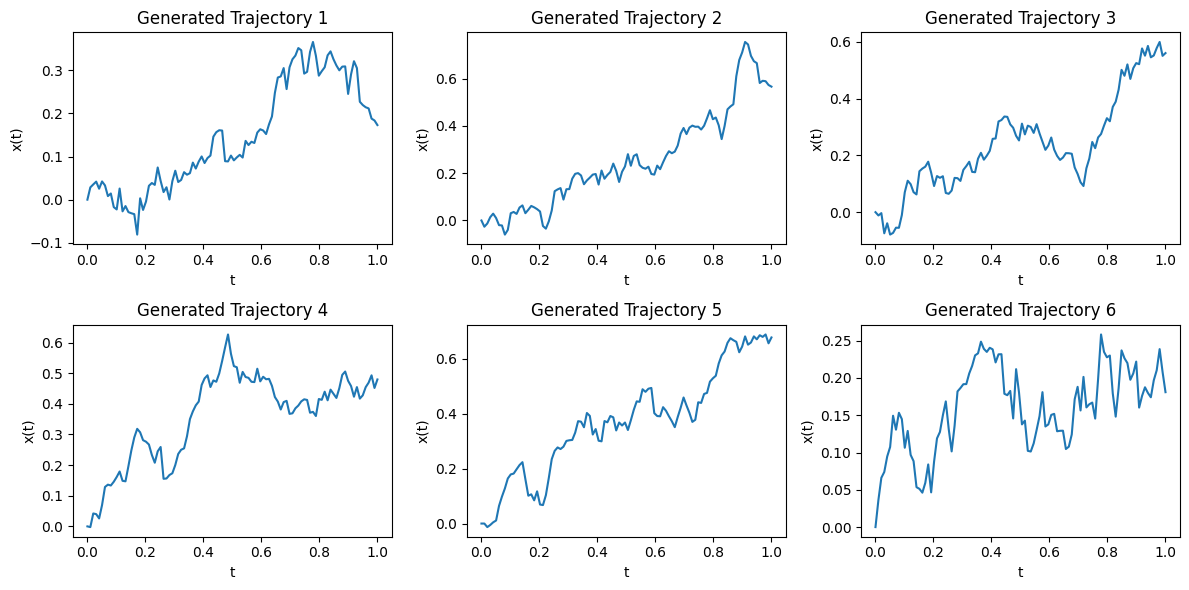

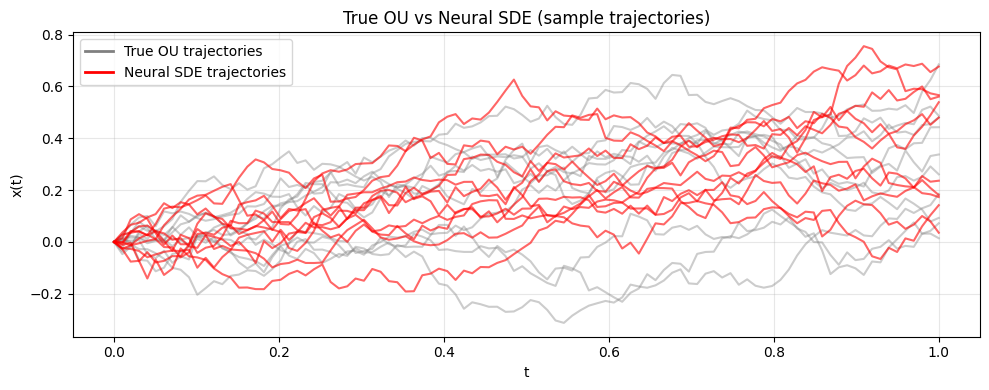

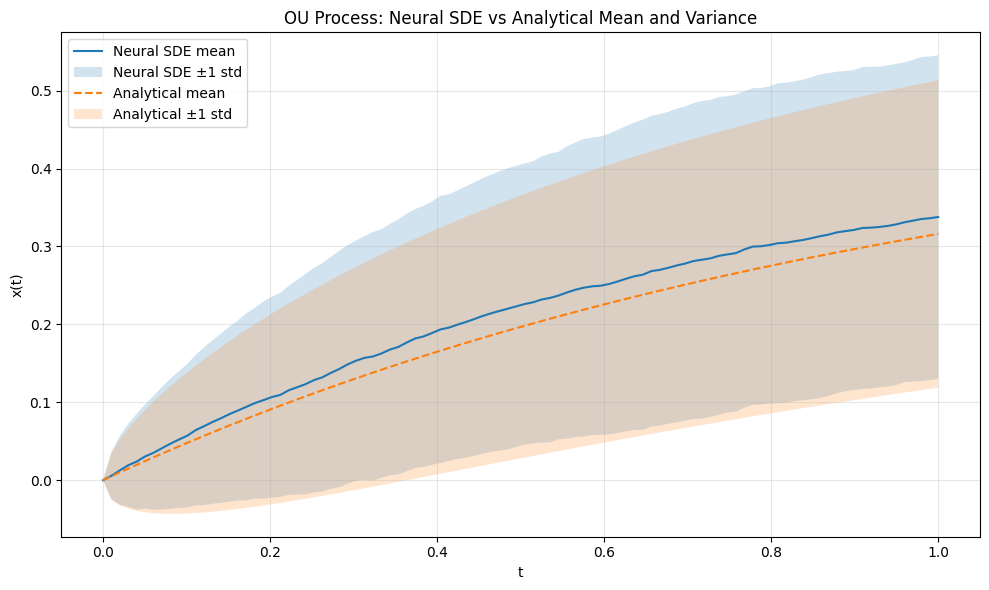

In [7]:
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np

# ----------------------------
# Generate trajectories from the trained Neural SDE
# ----------------------------
x0 = 0.0
n_gen = 1000

key_eval = jax.random.PRNGKey(123)
eval_keys = jax.random.split(key_eval, n_gen)

neural_paths = jax.vmap(lambda k: model(ts, x0, key=k))(eval_keys)  # (n_gen, N)

# ----------------------------
# 1) Qualitative check: generated sample trajectories
# ----------------------------
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for i, ax in enumerate(axes.flatten()):
    ax.plot(ts, neural_paths[i])
    ax.set_title(f"Generated Trajectory {i+1}")
    ax.set_xlabel("t")
    ax.set_ylabel("x(t)")

plt.tight_layout()
plt.show()

# overlay true OU trajectories vs Neural SDE trajectories
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
for i in range(10):
    ax.plot(ts, trajectories[i], color="gray", alpha=0.4)
for i in range(10):
    ax.plot(ts, neural_paths[i], color="red", alpha=0.6)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="gray", lw=2, label="True OU trajectories"),
    Line2D([0], [0], color="red", lw=2, label="Neural SDE trajectories"),
]
ax.legend(handles=legend_elements)
ax.set_title("True OU vs Neural SDE (sample trajectories)")
ax.set_xlabel("t")
ax.set_ylabel("x(t)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------
# 2) Quantitative check: mean and variance vs analytical OU statistics
# ----------------------------
neural_mean = jnp.mean(neural_paths, axis=0)
neural_std = jnp.std(neural_paths, axis=0)

theo_mean = mu + (x0 - mu) * jnp.exp(-theta * ts)
theo_std = jnp.sqrt((sigma**2 / (2 * theta)) * (1 - jnp.exp(-2 * theta * ts)))

plt.figure(figsize=(10, 6))

plt.plot(ts, neural_mean, label="Neural SDE mean")
plt.fill_between(
    ts,
    neural_mean - neural_std,
    neural_mean + neural_std,
    alpha=0.2,
    label="Neural SDE ±1 std",
)

plt.plot(ts, theo_mean, "--", label="Analytical mean")
plt.fill_between(
    ts,
    theo_mean - theo_std,
    theo_mean + theo_std,
    alpha=0.2,
    label="Analytical ±1 std",
)

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("OU Process: Neural SDE vs Analytical Mean and Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Discussion and Conclusion

The results show that the Neural SDE successfully learns the underlying dynamics of the Ornstein–Uhlenbeck process. Trajectories generated from the trained model are qualitatively similar to those in the dataset, exhibiting the same mean-reverting behavior and level of stochastic variability.

Beyond visual inspection, this agreement is confirmed quantitatively. The empirical mean and variance of trajectories generated by the Neural SDE closely match the analytical mean and variance of the OU process across time. This indicates that the model has learned both the deterministic drift and the stochastic diffusion components of the system, rather than collapsing to average behavior.

A key advantage of this approach is that it produces a *distribution over future trajectories* rather than a single point forecast. This makes Neural SDEs well suited for forecasting tasks where uncertainty is intrinsic to the system, as predictions can be accompanied by meaningful confidence intervals. Similarly, the model can be used for interpolation between observations while providing uncertainty estimates, which is valuable in settings with noisy or incomplete data.

Overall, this experiment demonstrates that Neural SDEs provide a principled and effective framework for modeling stochastic time series in data space. By combining flexible neural parameterizations with likelihood-based training, they offer a powerful tool for probabilistic forecasting and uncertainty-aware modeling of dynamical systems.